In [2]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import os

DATA_DIR = "../data/jsonl"
TRAIN_PATH = os.path.join(DATA_DIR, "vihallu-train.jsonl")
TEST_PATH = os.path.join(DATA_DIR, "vihallu-public-test.jsonl")

pd.set_option("display.max_colwidth", 150)

In [3]:
def load_jsonl(path):
    with open(path, "r", encoding="utf-8") as f:
        return [json.loads(line) for line in f]

train_data = load_jsonl(TRAIN_PATH)
test_data = load_jsonl(TEST_PATH)

train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)

print("Số mẫu train:", len(train_df))
print("Số mẫu test:", len(test_df))
train_df.head()

Số mẫu train: 7000
Số mẫu test: 1000


,id,context,prompt,response,label
0,9b1ea51d-d1ff-45ba-8cf1-6a91328e8600,"Vào những năm 1870, hai nhà điêu khắc Augustus Saint-Gaudens và Daniel Chester French sinh sống và làm việc gần Quảng trường. Đến những năm 1920, ...","Vào những năm 1960, nơi nào trở thành trung tâm của thế hệ âm nhạc beat và folk, mặc dù Jackson Pollock và Willem de Kooning đã tổ chức nhiều buổi...","Quảng trường Washington là trung tâm của thế hệ âm nhạc beat và folk vào những năm 1960. Ngoài ra, nơi đây từng là địa điểm tổ chức các buổi triển...",extrinsic
1,db7a89c6-2a6a-42af-beef-58e557ecc819,"Cách mạng Tháng Mười đã biến một cuộc chiến tranh đế quốc thành một cuộc đấu tranh chống lại sự đàn áp, đánh dấu sự khởi đầu của một phong trào qu...","Cách mạng Tháng Mười đã khởi xướng chủ nghĩa phát xít, một biến thể của chủ nghĩa đế quốc, đúng hay sai?","Sai. Cách mạng Tháng Mười đã đánh bại chủ nghĩa phát xít, một biến thể phản động của chủ nghĩa đế quốc, và không khởi xướng nó.",no
2,10fca062-d343-4eca-8434-93c7a8aa5e0e,"Vị trí địa lý nằm giữa phương Đông và Địa Trung Hải giúp cho người Thổ Nhĩ Kỳ hoàn toàn kiểm soát các tuyến đường mậu dịch lớn, và có một môi trưở...","Dựa trên việc Đế quốc Ottoman không bao giờ kiểm soát đường mậu dịch lớn, bạn có thể cho biết khi nào nền ẩm thực của Thổ Nhĩ Kỳ được xây dựng?","Nền ẩm thực của Thổ Nhĩ Kỳ được xây dựng từ giữa thập niên 1400, chịu ảnh hưởng của các đế quốc xung quanh như Byzantine và Ba Tư. Sự giao thoa vă...",extrinsic
3,ece8eb9e-d6bb-407a-a567-d9531861c603,"Hồ Quý Ly trước có tên là Lê Quý Ly (黎季犛), biểu tự Lý Nguyên (理元). Ông sinh năm Ất Hợi (1335), quê ở Đại Lại, Vĩnh Lộc (nay là xã Hà Đông, huyện H...",Đời cháu thứ 12 của Hồ Hưng Dật sống ở đâu?,"Đời cháu thứ 12 của Hồ Hưng Dật, là Hồ Liêm, sống ở hương Đại Lại, Vĩnh Lộc, Thanh Hóa.",no
4,b613217f-df2a-491e-8326-25811a31eb09,"Năm 2007, Bồ Đào Nha có khoảng 332.137 người nhập cư hợp pháp. Đến năm 2015, Bồ Đào Nha có khoảng 383.759 người nhập cư hợp pháp, chiếm 3,7% dân s...","Từ thập niên 1990, tại sao xuất hiện một vài làn sóng nhập cư mới của người Ukraina, Brasil, các cựu thuộc địa của Bồ Đào Nha tại châu Phi, mặc dù...","Mặc dù Bồ Đào Nha đã đóng cửa biên giới hoàn toàn từ thập niên 1990, làn sóng nhập cư mới từ Ukraina, Brasil và các cựu thuộc địa ở châu Phi vẫn d...",intrinsic


In [4]:
print("Các cột trong train:", list(train_df.columns))
print("Các cột trong test:", list(test_df.columns))

print("\nThông tin train")
train_df.info()

print("\nSố lượng giá trị null")
print(train_df.isnull().sum())

Các cột trong train: ['id', 'context', 'prompt', 'response', 'label']
Các cột trong test: ['id', 'context', 'prompt', 'response', 'predict_label']

Thông tin train
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7000 non-null   object
 1   context   7000 non-null   object
 2   prompt    7000 non-null   object
 3   response  7000 non-null   object
 4   label     7000 non-null   object
dtypes: object(5)
memory usage: 273.6+ KB

Số lượng giá trị null
id          0
context     0
prompt      0
response    0
label       0
dtype: int64


C:\Users\nghoo\AppData\Local\Temp\ipykernel_32852\4113487488.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")


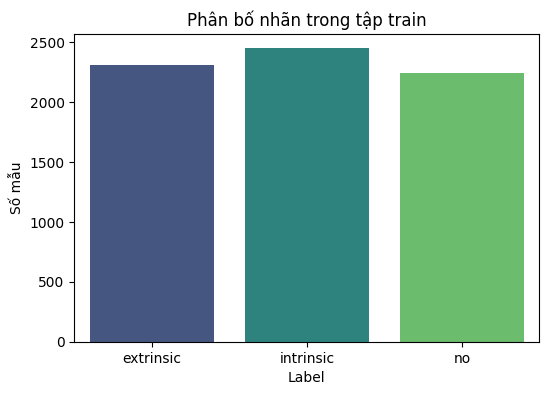

Tổng số nhãn: 3
label
extrinsic    2307
intrinsic    2448
no           2245
Name: count, dtype: int64


In [5]:
label_counts = train_df["label"].value_counts().sort_index()

plt.figure(figsize=(6,4))
sns.barplot(x=label_counts.index, y=label_counts.values, palette="viridis")
plt.title("Phân bố nhãn trong tập train")
plt.xlabel("Label")
plt.ylabel("Số mẫu")
plt.show()

print("Tổng số nhãn:", len(label_counts))
print(label_counts)

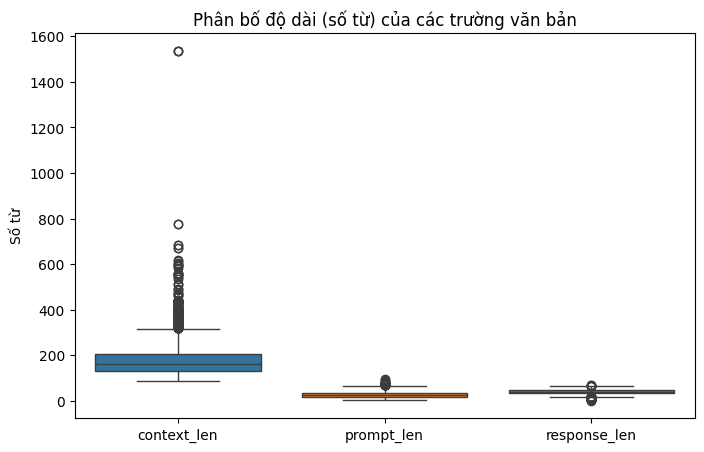

,context_len,prompt_len,response_len
count,7000.000000,7000.000000,7000.000000
mean,179.695714,26.760714,39.476857
std,72.473282,13.385212,10.264012
min,88.000000,3.000000,1.000000
25%,132.000000,15.000000,34.000000
50%,161.000000,26.000000,40.000000
75%,206.000000,36.000000,46.000000
max,1537.000000,94.000000,68.000000


In [6]:
for col in ["context", "prompt", "response"]:
    train_df[f"{col}_len"] = train_df[col].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))
sns.boxplot(data=train_df[["context_len", "prompt_len", "response_len"]])
plt.title("Phân bố độ dài (số từ) của các trường văn bản")
plt.ylabel("Số từ")
plt.show()

train_df[["context_len", "prompt_len", "response_len"]].describe()

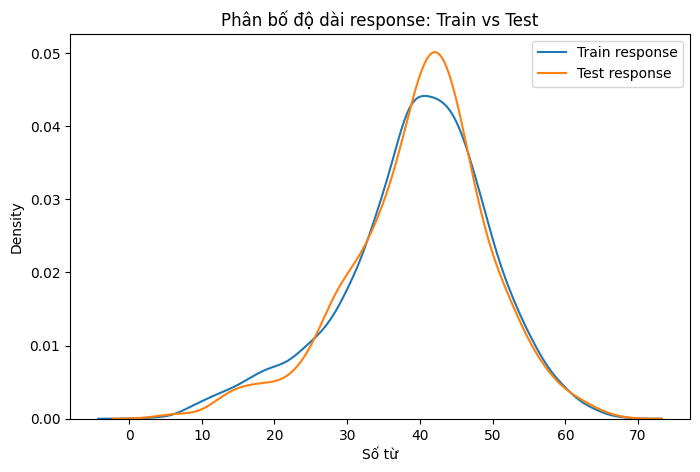

In [7]:
for col in ["context", "prompt", "response"]:
    test_df[f"{col}_len"] = test_df[col].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))
sns.kdeplot(train_df["response_len"], label="Train response")
sns.kdeplot(test_df["response_len"], label="Test response")
plt.title("Phân bố độ dài response: Train vs Test")
plt.xlabel("Số từ")
plt.legend()
plt.show()

In [8]:
sample = train_df.sample(5, random_state=42)
for i, row in sample.iterrows():
    print(f"ID: {row['id']}")
    print(f"Context: {row['context'][:150]}...")
    print(f"Prompt: {row['prompt']}")
    print(f"Response: {row['response'][:150]}...")
    print(f"Label: {row['label']}")
    print("="*80)

ID: 05a41ef4-6150-4db2-82f2-deae4b818083
Context: Vào năm 1982, Jackson thu âm ca khúc "Someone in the Dark" cho album nhạc truyện của bộ phim E.T the Extra-Terrestrial. Bài hát do Quincy Jones sản xu...
Prompt: "Thriller" đã đạt được kỷ lục gì trong ngành công nghiệp âm nhạc, mặc dù thực tế là nó chưa bao giờ lọt vào top 10 Billboard Hot 100?
Response: Thriller cũng là album đầu tiên sử dụng kỹ thuật âm thanh vòm 5.1, mang đến trải nghiệm nghe nhạc vượt trội cho người dùng. Điều này đã góp phần định ...
Label: extrinsic
ID: 9874108d-6a58-461e-9514-4122cfd37d58
Context: Bốn quy tắc súc tích và tổng quát cho nghiên cứu khoa học này đã là một cuộc cách mạng về tư duy thực sự vào thời điểm bấy giờ. Thực hiện các quy tắc ...
Prompt: Newt0n dã hoan thàn phuong phap của ai?
Response: Newton đã hoàn thiện phương pháp thực nghiệm của Galileo Galilei....
Label: no
ID: 8cd7a551-c285-4b88-8f73-2fc9ead99006
Context: Vận tải công cộng tại Síp bị hạn chế bởi các dịch vụ bus tư nhân (ngoại trừ Nicosi